In [5]:
import numpy as np
np.random.seed(42)

data = {
    'CustomerID': range(1, 101),
    'Age': np.random.randint(18, 65, 100),
    'Annual_Income': np.random.randint(20000, 120000, 100),
    'Purchase_Frequency': np.random.randint(1, 30, 100),
    'Avg_Order_Value': np.random.randint(50, 500, 100),
    'Total_Spent': np.random.randint(500, 50000, 100)
}

df = pd.DataFrame(data)
print(df.head(10))
print(f"\nTotal Customers: {len(df)}")

   CustomerID  Age  Annual_Income  Purchase_Frequency  Avg_Order_Value  \
0           1   56          22695                  17              353   
1           2   46          68190                  26              257   
2           3   32          25258                  20              180   
3           4   60         107538                  12              453   
4           5   25          59504                   7              201   
5           6   38          53159                   2              103   
6           7   56          33986                   3              169   
7           8   36          81858                  17              210   
8           9   40          32666                   5              457   
9          10   28          58660                  17              165   

   Total_Spent  
0        27141  
1        35084  
2        33245  
3        23593  
4         1069  
5        38710  
6        35163  
7        37131  
8        46181  
9         7955 

In [6]:
features = ['Age', 'Annual_Income', 'Purchase_Frequency', 'Avg_Order_Value', 'Total_Spent']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaled successfully!")

Data scaled successfully!


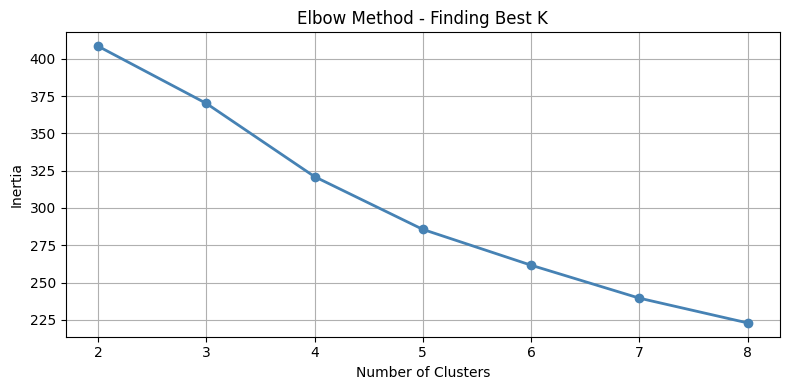

In [7]:
inertia = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_chart.png')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Segment'] = kmeans.fit_predict(X_scaled)

segment_names = {0: 'Budget Shoppers', 1: 'Premium Customers', 
                 2: 'Occasional Buyers', 3: 'Loyal High Spenders'}
df['Segment_Name'] = df['Segment'].map(segment_names)

print(df['Segment_Name'].value_counts())

Segment_Name
Premium Customers      33
Loyal High Spenders    23
Occasional Buyers      23
Budget Shoppers        21
Name: count, dtype: int64


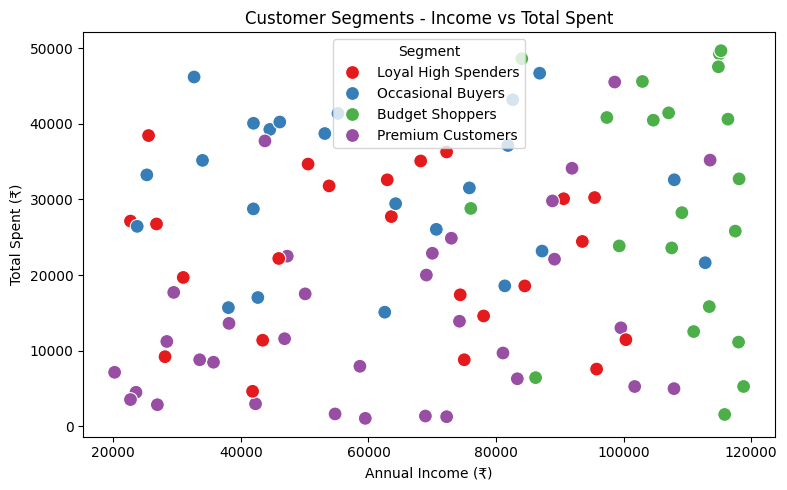

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Total_Spent', 
                hue='Segment_Name', palette='Set1', s=100)
plt.title('Customer Segments - Income vs Total Spent')
plt.xlabel('Annual Income (₹)')
plt.ylabel('Total Spent (₹)')
plt.legend(title='Segment')
plt.tight_layout()
plt.savefig('customer_segments.png')
plt.show()

In [10]:
summary = df.groupby('Segment_Name')[features].mean().round(0)
print("\n====== SEGMENT SUMMARY ======")
print(summary)



====== SEGMENT SUMMARY ======
                      Age  Annual_Income  Purchase_Frequency  Avg_Order_Value  \
Segment_Name                                                                    
Budget Shoppers      50.0       107069.0                 8.0            307.0   
Loyal High Spenders  51.0        61924.0                23.0            326.0   
Occasional Buyers    43.0        60576.0                10.0            166.0   
Premium Customers    27.0        61972.0                16.0            299.0   

                     Total_Spent  
Segment_Name                      
Budget Shoppers          29517.0  
Loyal High Spenders      22645.0  
Occasional Buyers        31619.0  
Premium Customers        14284.0  


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler